# Дизайн и проверка A/B-теста

В исходных данных Online Retail II нет настоящего A/B-теста.

Я буду использовать исторические данные, чтобы спроектировать будущий эксперимент:

- выбрать гипотезу
- выбрать основную метрику
- выбрать вспомогательные и guardrail метрики
- корректно обработать AOV как ratio-метрику + применить CUPED
- провести A/A-симуляцию
- проверить результат через t-тест и бутстрап

In [365]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import norm

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Загрузка данных

Берём сохраненный аггрегат заказов из продуктового ноутбука.

Для A/B-теста нужна единица рандомизации. В этом проекте логичнее рандомизировать пользователей.

Но целевая метрика AOV - метрика отношения.

Поэтому на уровне пользователя я буду хранить только числитель и знаменатель для AOV: revenue и orders.

In [366]:
orders = pd.read_csv('../data/aggregates/orders.csv', parse_dates=['InvoiceDate', 'InvoiceDateOnly', 'InvoiceMonth'])

orders.head()

,Invoice,CustomerID,Country,InvoiceDate,IsReturn,IsSale,GrossRevenue,RefundAmount,NetRevenue,UniqueProducts,ItemsSold,ItemsReturned,InvoiceDateOnly,InvoiceMonth
0,489434,13085.0,United Kingdom,2009-12-01 07:45:00,False,True,505.30,0.0,505.30,8,166.0,NaN,2009-12-01,2009-12-01
1,489435,13085.0,United Kingdom,2009-12-01 07:46:00,False,True,145.80,0.0,145.80,4,60.0,NaN,2009-12-01,2009-12-01
2,489436,13078.0,United Kingdom,2009-12-01 09:06:00,False,True,630.33,0.0,630.33,19,193.0,NaN,2009-12-01,2009-12-01
3,489437,15362.0,United Kingdom,2009-12-01 09:08:00,False,True,310.75,0.0,310.75,23,145.0,NaN,2009-12-01,2009-12-01
4,489438,18102.0,United Kingdom,2009-12-01 09:24:00,False,True,2286.24,0.0,2286.24,17,826.0,NaN,2009-12-01,2009-12-01


In [367]:
sales_orders = orders[(orders['IsSale']) & (orders['CustomerID'].notna())].copy()
return_orders = orders[(orders['IsReturn']) & (orders['CustomerID'].notna())].copy()

sales_orders['CustomerID'] = sales_orders['CustomerID'].astype(int)
return_orders['CustomerID'] = return_orders['CustomerID'].astype(int)

## 2. Гипотеза эксперимента

Гипотеза:

- Если добавить на экран корзины блок с рекомендациями дополнительных товаров, то пользователи будут добавлять больше товаров в заказ, и средний чек вырастет.

Вариант A — обычный экран корзины.

Вариант B — экран корзины с блоком рекомендаций.

Основная метрика:

- AOV = GrossRevenue / SalesOrders

Дополнительные метрики:

- Revenue per Customer
- Orders per Customer
- Items per Order

Guardrail-метрика:

- Return Orders Rate = ReturnOrders / SalesOrders

## 3. Baseline-период

Последний месяц в датасете неполный. Я беру в качестве исторических данных (бейзлайна) год до последнего месяца, по ним оценивается размер выборки и MDE.

На данных еще за год до исторических (pre-baseline) я считаю ковариату (исторический линеаризованный AOV) для расчета линеаризованного CUPED AOV в бейзлайне.

In [368]:
last_month = sales_orders['InvoiceMonth'].drop_duplicates().sort_values().iloc[-1]
start_month = last_month - pd.DateOffset(years=1)

baseline_sales = sales_orders[
    (sales_orders['InvoiceMonth'] >= start_month) &
    (sales_orders['InvoiceMonth'] < last_month)
].copy()

baseline_returns = return_orders[
    (return_orders['InvoiceMonth'] >= start_month) &
    (return_orders['InvoiceMonth'] < last_month)
].copy()

print('Период бейзлайна:', start_month.date(), '-', last_month.date())
print('Заказы:', baseline_sales['Invoice'].nunique())
print('Клиенты:', baseline_sales['CustomerID'].nunique())

Период бейзлайна: 2010-12-01 - 2011-12-01
Заказы: 17626
Клиенты: 4293


## 4. Таблица пользователей для эксперимента

Пользовательская таблица нужна для того, чтобы у каждой единицы рандомизации были числитель и знаменатель ratio-метрики.

In [369]:
customer_data = baseline_sales.groupby('CustomerID').agg(
    revenue=('GrossRevenue', 'sum'),
    orders=('Invoice', 'nunique'),
    items=('ItemsSold', 'sum')
).reset_index()

customer_baseline_refunds = baseline_returns.groupby('CustomerID').agg(
    return_orders=('Invoice', 'nunique')
).reset_index()

customer_data = customer_data.merge(customer_baseline_refunds, on='CustomerID', how='left')
customer_data['return_orders'] = customer_data['return_orders'].fillna(0)

customer_data.head()

,CustomerID,revenue,orders,items,return_orders
0,12346,77183.60,1,74215.0,1.0
1,12347,4796.97,6,2585.0,0.0
2,12348,1437.24,4,2332.0,0.0
3,12349,1457.55,1,630.0,0.0
4,12350,294.40,1,196.0,0.0


In [370]:
aov = customer_data['revenue'].sum() / customer_data['orders'].sum()
print('AOV из таблицы пользователей:', aov)

AOV из таблицы пользователей: 485.49642403267904


## 5. Линеаризация AOV

Для каждого пользователя считаем:

linearized_aov = revenue - R * orders

In [371]:
r = aov
customer_data['linearized_aov'] = customer_data['revenue'] - r * customer_data['orders']

customer_data['linearized_aov'].describe()

count    4.293000e+03
mean    -2.169398e-13
std      7.167861e+03
min     -6.243578e+04
25%     -7.558593e+02
50%     -3.341964e+02
75%     -8.018642e+01
max      2.483331e+05
Name: linearized_aov, dtype: float64

## 6. CUPED для линеаризованной AOV

Ковариата - историческое значение той же метрики за предыдущий 12-месячный период.

Для пользователей без покупок в историческом периоде ковариата принимается равной нулю, что соответствует отсутствию исторической активности.

In [372]:
pre_period_start = start_month - pd.DateOffset(years=1)

historical_sales = sales_orders[
    (sales_orders['InvoiceMonth'] >= pre_period_start) &
    (sales_orders['InvoiceMonth'] < start_month)
].copy()

historical_customer_data = historical_sales.groupby('CustomerID').agg(
    historical_revenue=('GrossRevenue', 'sum'),
    historical_orders=('Invoice', 'nunique')
).reset_index()

customer_data = customer_data.merge(historical_customer_data, on='CustomerID', how='left')
customer_data[['historical_revenue', 'historical_orders']] = customer_data[
    ['historical_revenue', 'historical_orders']
].fillna(0)

customer_data['historical_linearized_aov'] = (
    customer_data['historical_revenue'] - r * customer_data['historical_orders']
)

x = customer_data['historical_linearized_aov']
y = customer_data['linearized_aov']

theta = np.cov(y, x, ddof=1)[0, 1] / np.var(x, ddof=1)
customer_data['cuped_linearized_aov'] = y - theta * (x - x.mean())

variance_before_cuped = customer_data['linearized_aov'].var(ddof=1)
variance_after_cuped = customer_data['cuped_linearized_aov'].var(ddof=1)
variance_reduction = 1 - variance_after_cuped / variance_before_cuped

print('Период исторической ковариаты:', pre_period_start.date(), '-', start_month.date())
print(f'Дисперсия до CUPED: {variance_before_cuped:.2f}')
print(f'Дисперсия после CUPED: {variance_after_cuped:.2f}')
print(f'Снижение дисперсии на исторических данных: {variance_reduction:.2%}')

Период исторической ковариаты: 2009-12-01 - 2010-12-01
Дисперсия до CUPED: 51378234.85
Дисперсия после CUPED: 13649409.45
Снижение дисперсии на исторических данных: 73.43%


Эффективность CUPED зависит от доли пользователей с историей покупок. Если в реальном эксперименте будет много новых пользователей, снижение дисперсии может быть слабее.

## 7. Расчёт размера выборки

Считаем размер выборки для нескольких MDE.

В таблице MDE задан в единицах линеаризованной метрики. Для интерпретации он дополнительно переводится в относительное изменение AOV через среднюю выручку на пользователя.

MDE = MDE / числитель ratio-метрики * 100%

In [373]:
alpha = 0.05
power = 0.8

z_alpha = norm.ppf(1 - alpha / 2)
z_beta = norm.ppf(power)

sigma = customer_data['cuped_linearized_aov'].std(ddof=1)
monthly_customers = baseline_sales.groupby('InvoiceMonth')['CustomerID'].nunique().mean()
avg_numerator = customer_data['revenue'].mean()

sample_size_rows = []

for mde in [x for x in range(500, 1500, 50)]:
    n = ((z_alpha + z_beta)**2 * 2 * sigma**2) / mde**2

    total_customers = n * 2

    duration_months = total_customers / monthly_customers

    mde_percent = mde / avg_numerator

    sample_size_rows.append({
        'mde_linearized': mde,
        'mde_percent': f'{mde_percent:.2%}',
        'n': int(n) + 1,
        'total_customers': int(total_customers) + 1,
        'duration_months': round(duration_months, 3)
    })

sample_size = pd.DataFrame(sample_size_rows)

print('Среднее кол-во клиентов за месяц:', int(monthly_customers))
sample_size

Среднее кол-во клиентов за месяц: 1034


,mde_linearized,mde_percent,n,total_customers,duration_months
0,500,25.08%,858,1715,1.658
1,550,27.59%,709,1417,1.370
2,600,30.10%,596,1191,1.151
3,650,32.61%,508,1015,0.981
4,700,35.12%,438,875,0.846
5,750,37.63%,381,762,0.737
6,800,40.13%,335,670,0.648
7,850,42.64%,297,594,0.574
8,900,45.15%,265,530,0.512
9,950,47.66%,238,475,0.459


Тест получился не очень чувствительным. Примерно за месяц эксперимента собирается около 1000 пользователей, при таком размере выборки мы можем контролировать уровень ошибки II рода только при размере эффекта больше 32-35%, что очень много.

## 8. A/A-симуляция

Проверим, что выбранный статистический подход не создаёт слишком много ложных срабатываний.

В A/A-тесте настоящего эффекта нет, поэтому доля p-value меньше 0.05 должна быть около 5% и оно должно быть распределено равномерно.

In [374]:
np.random.seed(42)

p_values = []
aov_diffs = []

for _ in range(10000):
    sample = customer_data[[
        'CustomerID',
        'revenue',
        'orders',
        'historical_linearized_aov'
    ]].copy().sample(int(monthly_customers))
    sample['group'] = np.where(np.random.rand(len(sample)) < 0.5, 'A', 'B')

    control = sample[sample['group'] == 'A']
    test = sample[sample['group'] == 'B']

    r_control = control['revenue'].sum() / control['orders'].sum()
    sample['linearized_aov'] = sample['revenue'] - r_control * sample['orders']
    sample['cuped_linearized_aov'] = (
        sample['linearized_aov'] -
        theta * (sample['historical_linearized_aov'] - sample['historical_linearized_aov'].mean())
    )

    control = sample[sample['group'] == 'A']
    test = sample[sample['group'] == 'B']

    p_value = stats.ttest_ind(
        control['cuped_linearized_aov'],
        test['cuped_linearized_aov'],
    ).pvalue

    aov_a = control['revenue'].sum() / control['orders'].sum()
    aov_b = test['revenue'].sum() / test['orders'].sum()

    p_values.append(p_value)
    aov_diffs.append(aov_b / aov_a - 1)

true_alpha = (np.array(p_values) < alpha).mean()
print('Доля ошибок 1 рода:', true_alpha)

Доля ошибок 1 рода: 0.0373


На исторической пользовательской выборке выбранный подход контролирует долю ложноположительных срабатываний на уровне около 4%.

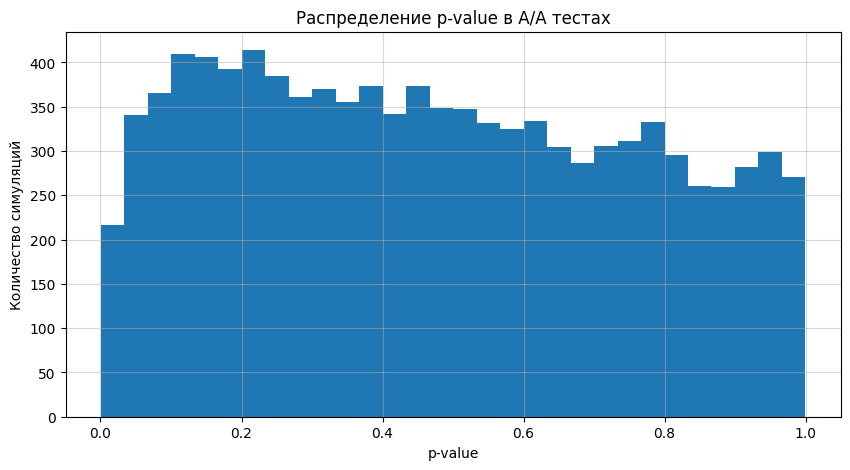

In [375]:
plt.figure(figsize=(10, 5))
plt.hist(p_values, bins=30)
plt.xlabel('p-value')
plt.ylabel('Количество симуляций')
plt.title('Распределение p-value в A/A тестах')
plt.grid(alpha=0.5)

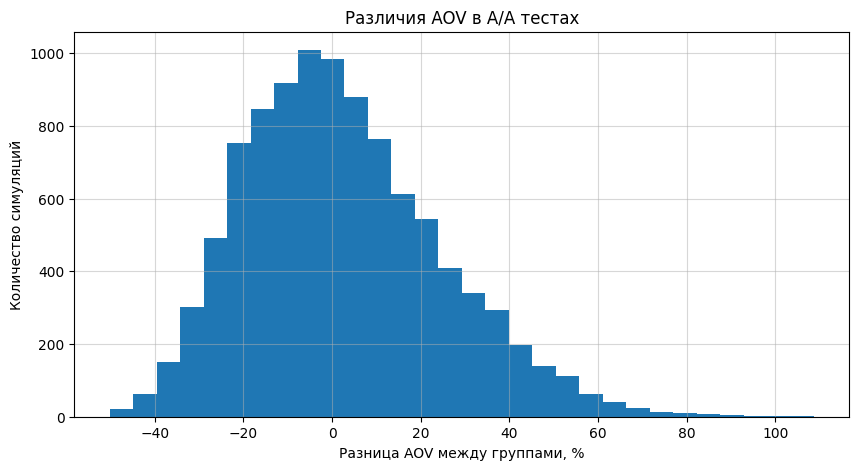

In [376]:
plt.figure(figsize=(10, 5))
plt.hist(np.array(aov_diffs) * 100, bins=30)
plt.xlabel('Разница AOV между группами, %')
plt.ylabel('Количество симуляций')
plt.title('Различия AOV в A/A тестах')
plt.grid(alpha=0.5)

## 9. Симуляция A/B теста


В синтетической симуляции эффект моделируется упрощённо. Группе B увеличивается revenue при неизменных orders/items. Поэтому дополнительные метрики используются только как демонстрация расчёта, а не как реалистичная модель поведения пользователей.

In [377]:
np.random.seed(42)

ab_data = customer_data[[
    'CustomerID',
    'revenue',
    'orders',
    'items',
    'return_orders',
    'historical_linearized_aov'
]].copy().sample(int(monthly_customers))
ab_data['group'] = np.where(np.random.rand(len(ab_data)) < 0.5, 'A', 'B')

simulated_uplift = 0.15
ab_data.loc[ab_data['group'] == 'B', 'revenue'] = ab_data.loc[ab_data['group'] == 'B', 'revenue'] * (1 + simulated_uplift)

ab_data.head()

,CustomerID,revenue,orders,items,return_orders,historical_linearized_aov,group
3530,17228,2601.3460,8,1743.0,0.0,-1512.282120,B
2894,16340,631.4305,1,501.0,0.0,5.997152,B
3119,16654,952.9705,4,345.0,1.0,-1059.185696,B
3864,17686,5876.6035,6,2183.0,0.0,1586.357152,B
3693,17455,151.4550,1,66.0,0.0,0.000000,B


In [378]:
ab_metrics = ab_data.groupby('group').agg(
    customers=('CustomerID', 'nunique'),
    revenue=('revenue', 'sum'),
    orders=('orders', 'sum'),
    items=('items', 'sum'),
    return_orders=('return_orders', 'sum')
).reset_index()

ab_metrics['aov'] = ab_metrics['revenue'] / ab_metrics['orders']
ab_metrics['revenue_per_customer'] = ab_metrics['revenue'] / ab_metrics['customers']
ab_metrics['orders_per_customer'] = ab_metrics['orders'] / ab_metrics['customers']
ab_metrics['items_per_order'] = ab_metrics['items'] / ab_metrics['orders']
ab_metrics['return_orders_rate'] = ab_metrics['return_orders'] / ab_metrics['orders']

ab_metrics

,group,customers,revenue,orders,items,return_orders,aov,revenue_per_customer,orders_per_customer,items_per_order,return_orders_rate
0,A,506,1026323.810,2336,600520.0,453.0,439.350946,2028.307925,4.616601,257.071918,0.193921
1,B,528,963791.471,1969,482610.0,378.0,489.482718,1825.362634,3.729167,245.104114,0.191976


Дополнительные и guardrail-метрика в рамках ноутбука анализируются описательно. Основное статистическое решение принимается по заранее выбранной основной метрике.

In [379]:
aov_a = ab_metrics[ab_metrics['group'] == 'A']['aov'].iloc[0]
aov_b = ab_metrics[ab_metrics['group'] == 'B']['aov'].iloc[0]
observed_uplift = aov_b / aov_a - 1

print(f'AOV A: {aov_a:.2f}')
print(f'AOV B: {aov_b:.2f}')
print(f'Наблюдаемый прирост: {observed_uplift:.2%}')

AOV A: 439.35
AOV B: 489.48
Наблюдаемый прирост: 11.41%


### 9.1. t-тест (линеаризация + CUPED)

Сначала считаю линеаризованную AOV, затем применяю CUPED с исторической линеаризованной AOV в качестве ковариаты.

In [380]:
control = ab_data[ab_data['group'] == 'A'].copy()
test = ab_data[ab_data['group'] == 'B'].copy()

k_control = control['revenue'].sum() / control['orders'].sum()

ab_data['linearized_aov'] = ab_data['revenue'] - k_control * ab_data['orders']

ab_data['cuped_linearized_aov'] = (
    ab_data['linearized_aov'] -
    theta * (ab_data['historical_linearized_aov'] - ab_data['historical_linearized_aov'].mean())
)

control = ab_data[ab_data['group'] == 'A']
test = ab_data[ab_data['group'] == 'B']

cuped_test_result = stats.ttest_ind(
    control['cuped_linearized_aov'],
    test['cuped_linearized_aov'],
    equal_var=False
)

print('p-value:', cuped_test_result.pvalue)

p-value: 0.005675394181164495


p-value ниже 0.05 на CUPED линеаризованной метрке, есть основания отклонить нулевую гипетезу. Статистически значимый эффект зафиксирован.

### 9.2. Bootstrap для AOV

Это удобный способ получить доверительный интервал для прироста ratio-метрики.

In [ ]:
np.random.seed(42)

boot_uplifts = []

for _ in range(30000):
    sample_a = control.sample(len(control), replace=True)
    sample_b = test.sample(len(test), replace=True)

    boot_aov_a = sample_a['revenue'].sum() / sample_a['orders'].sum()
    boot_aov_b = sample_b['revenue'].sum() / sample_b['orders'].sum()

    boot_uplifts.append(boot_aov_b / boot_aov_a - 1)

ci = np.percentile(boot_uplifts, [2.5, 97.5])

print(f'Средний прирост AOV в бутстрапе: {np.mean(boot_uplifts):.2%}')
print(f'95% CI: [{ci[0]:.2%}; {ci[1]:.2%}]')

Bootstrap uplift mean: 12.21%
95% CI: [-6.48%; 34.55%]


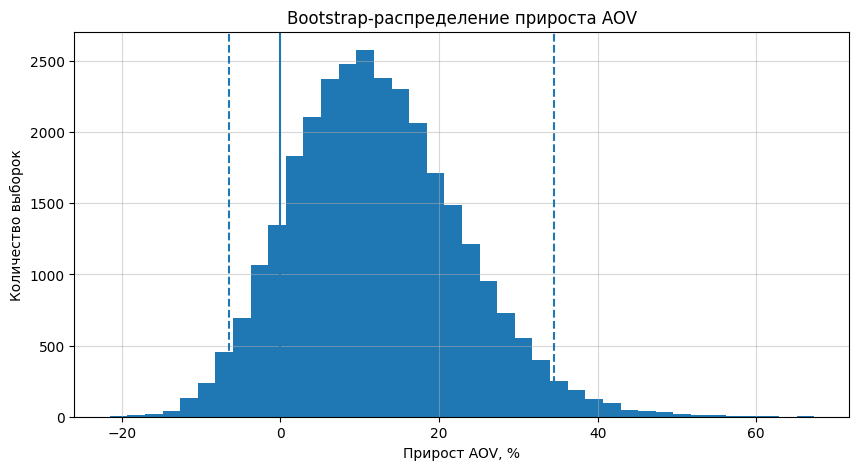

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(np.array(boot_uplifts) * 100, bins=40)
plt.axvline(ci[0] * 100, linestyle='--')
plt.axvline(ci[1] * 100, linestyle='--')
plt.axvline(0, linestyle='-')
plt.xlabel('Прирост AOV, %')
plt.ylabel('Количество выборок')
plt.title('Бутстрап-распределение прироста AOV')
plt.grid(alpha=0.5)

### 9.3. Guardrail-метрики

Return Orders Rate тоже является ratio-метрикой.

In [383]:
guardrail_metrics = ab_data.groupby('group').agg(
    orders=('orders', 'sum'),
    return_orders=('return_orders', 'sum')
).reset_index()

guardrail_metrics['return_orders_rate'] = guardrail_metrics['return_orders'] / guardrail_metrics['orders']

guardrail_metrics

,group,orders,return_orders,return_orders_rate
0,A,2336,453.0,0.193921
1,B,1969,378.0,0.191976


### Выводы синтетического A/B эксперимента

- Наблюдаемый прирост у AOV: 11.41%

- Для синтетического A/B-теста были применены два подхода к проверке гипотезы: t-тест для CUPED линеаризованной метрики и бутстрап.

- Основной метод анализа - t-тест на CUPED скорректированной линеаризованной метрике.

- Основной CUPED подход показал статистически значимый эффект. Бутстрап для сырой AOV дал широкий доверительный интервал, включающий ноль, что показывает высокую неопределённость при анализе исходной ratio-метрики без снижения дисперсии.

- В синтетической симуляции guardrail-метрика Return Orders Rate не показала ухудшения.

## 10. Экспорт результатов

In [384]:
customer_data.to_csv('../data/ab/ab_customer_baseline.csv', index=False)
sample_size.to_csv('../data/ab/ab_sample_size.csv', index=False)
ab_metrics.to_csv('../data/ab/ab_simulation_metrics.csv', index=False)
ab_data.to_csv('../data/ab/ab_experiment_data.csv', index=False)

## 11. Итоговые выводы

В этом ноутбуке был спроектирован и проверен пайплайн A/B-теста для гипотезы о добавлении блока рекомендаций на экран корзины. Основной продуктовой метрикой была выбрана AOV, так как ожидаемый эффект изменения должен проявляться в росте среднего чека.

Так как AOV является ratio-метрикой, для статистической проверки использовалась линеаризация. Это позволяет перейти от отношения revenue / orders к пользовательской метрике, с которой можно применять стандартные статистические тесты. Дополнительно к линеаризованной AOV был применён CUPED с исторической активностью пользователя в качестве ковариаты.

На исторических данных CUPED снизил дисперсию линеаризованной AOV на 73.43%. Это существенно повышает чувствительность теста и уменьшает требуемый размер выборки по сравнению с анализом исходной метрики без корректировки.

Расчёт размера выборки показал, что при среднем потоке около 1000 пользователей в месяц эксперимент остаётся достаточно дорогим по данным: за период около одного месяца можно уверенно детектировать только крупные эффекты порядка 32–35% относительно AOV. Поэтому для меньших эффектов потребовалось бы либо увеличивать длительность эксперимента, либо использовать дополнительные способы снижения дисперсии.
Корректность выбранного статистического подхода была проверена с помощью A/A симуляции. Доля ложноположительных срабатываний составила 3.73%, что близко к заданному уровню значимости 5%. Это говорит о том, что t-test на CUPED-скорректированной линеаризованной метрике не завышает ошибку первого рода на исторических данных.

В синтетическом A/B тесте группе B был искусственно добавлен эффект к revenue. Наблюдаемый прирост AOV составил 11.41%. Основной статистический тест на CUPED-скорректированной линеаризованной AOV показал статистически значимый результат: p-value = 0.0057.

При этом бутстрап для сырой AOV дал широкий 95% доверительный интервал по приросту: от -6.48% до 34.55%. Интервал включает ноль, поэтому бутстрап без CUPED не даёт статистически значимого подтверждения эффекта. Это расхождение интерпретируется не как противоречие, а как следствие высокой дисперсии исходной ratio-метрики и более низкой чувствительности бутстрапа без CUPED на выбранном размере выборки.

Guardrail-метрика Return Orders Rate в синтетической симуляции не показала заметного ухудшения: в группе A она составила 19.39%, в группе B - 19.20%. Дополнительные метрики использовались как описательные и помогают оценить возможные побочные изменения, но основное статистическое решение принималось по заранее выбранной основной метрике AOV.